# Here I study commutation relations between different operators

To create a peaked random circuit with hidden string, I do modofications of some initial peaked circuit in which the string can be easily found. To do these modifications I need to commute some operators and made other changes. For example, I take a block of gates and replace it with another block doing the same thing but with very different parameters.

### Import libraries

In [27]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit import transpile

from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

import numpy as np
PI = np.pi
import math
import cmath

import random
# SciPy minimizer routine
from scipy.optimize import minimize

import matplotlib.pyplot as plt


### commutaton of CZ znd X:  X(2) * CZ(1,2) = CZ(1,2) * Z(1) * X(2), and  X(1) * CZ(1,2) = CZ(1,2) * Z(2) * X(1)

In [4]:
# commutaton of CZ znd X:  X(2) * CZ(1,2) = CZ(1,2) * Z(1) * X(2), and  X(1) * CZ(1,2) = CZ(1,2) * Z(2) * X(1)
q_1 = qiskit.QuantumCircuit(2)

q_1.x(1)
q_1.cz(1,0)
op = Operator(q_1)
display(array_to_latex(op, precision=1))

q_2 = qiskit.QuantumCircuit(2)
q_2.cz(1,0)
q_2.x(1)
q_2.z(0)
#q_aux_1 = transpile(q_2, basis_gates = ['cz','sx','z'])

op = Operator(q_2)
display(array_to_latex(op, precision=1))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Commutaton of Z(\theta) and X:  X(2) * P(\theta) = P(-\theta) * X * exp(-i * \theta)

In [6]:
# commutaton of Z(\theta) and X:  X(2) * P(\theta) = P(-\theta) * X * exp(-i * \theta)
q_1 = qiskit.QuantumCircuit(1)
th = PI/2
q_1.x(0)
q_1.p(th, 0)
op = Operator(q_1)
display(array_to_latex(op, precision=1))

q_2 = qiskit.QuantumCircuit(1)
q_2.p(-th, 0)
q_2.x(0)


op = -cmath.exp(-1j * th) * Operator(q_2)
display(array_to_latex(op, precision=1))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Commutaton of U3(\theta, \phi, \lambda) and X:  X * U3(\theta, \phi, \lambda) = U3(-\theta, -\phi, -\lambda) * X * 1j * exp(-i * (\theta - \phi - \lambda))

In [7]:
# commutaton of U3(\theta, \phi, \lambda) and X:  X * U3(\theta, \phi, \lambda) = U3(-\theta, -\phi, -\lambda) * X * 1j * exp(-i * (\theta - \phi - \lambda))
q_1 = qiskit.QuantumCircuit(1)
th = PI/2
ph = 2
lam = 3
q_1.x(0)
q_1.u(th, ph, lam, 0)
op = Operator(q_1)
display(array_to_latex(op, precision=1))

q_2 = qiskit.QuantumCircuit(1)
q_2.u(-th, -ph, -lam, 0)
q_2.x(0)



op = 1j*cmath.exp(-1j * (th - ph - lam)) * Operator(q_2)
display(array_to_latex(op, precision=1))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Commutaton of Z(\theta) znd X:  X) * U3(\theta, \phi, \lambda) = P(-\theta, -\phi, -\lambda) * X * 1j * exp(-i * (\theta - \phi - \lambda))

In [8]:
# commutaton of Z(\theta) znd X:  X) * U3(\theta, \phi, \lambda) = P(-\theta, -\phi, -\lambda) * X * 1j * exp(-i * (\theta - \phi - \lambda))
q_1 = qiskit.QuantumCircuit(1)
th = PI/7
ph = 3
lam = 0.4

q_1.u(th, ph, lam, 0)

op = Operator(q_1)
display(array_to_latex(op, precision=1))

q_aux = qiskit.QuantumCircuit(1)

q_aux.p(1,0)
q_aux.u(th, ph, lam, 0)
q_aux.p(3.8, 0)
q_aux.sx(0)

q_aux_1 = transpile(q_aux, basis_gates = ['u'])
cur_angle_1 = q_aux_1.data[0][0].params[0]
cur_angle_2 = q_aux_1.data[0][0].params[1]
cur_angle_3 = q_aux_1.data[0][0].params[2]

q_2 = qiskit.QuantumCircuit(1)
q_2.u(cur_angle_1, cur_angle_2, cur_angle_3, 0)



op = cmath.exp(1j * 1.000906) * Operator(q_2)
display(array_to_latex(op, precision=1))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

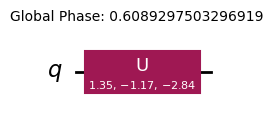

In [9]:
q_aux_1.draw('mpl')

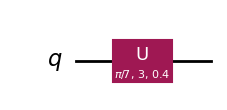

In [10]:
q_1.draw('mpl')

### R_xy(\phi_1, 0) x R_xy(\phi_2, 1) x CZ(0, 1) = CZ(0, 1) x R_xy(\phi_1 + PI / 2, 0) x R_xy(\phi_2 + PI / 2, 1)

In [11]:
# Commutation relation: R_xy(\phi, i) - rotation around axis in the xy plane by an angle PI. 
#The axis is rotated with respect to x by angle \phi. The operator is applied to the qubit i.
#So, R_xy(\phi_1, 0) x R_xy(\phi_2, 1) x CZ(0, 1) = CZ(0, 1) x R_xy(\phi_1 + PI / 2, 0) x R_xy(\phi_2 + PI / 2, 1)

q_1 = qiskit.QuantumCircuit(2)
rot_ang = PI


beta_1 = PI/5
beta_1_t = beta_1 + PI / 2
beta_2 = PI/3
beta_2_t = beta_2 + PI / 2



nx_1 = rot_ang * math.cos(beta_1)
ny_1 = rot_ang * math.sin(beta_1)
nx_2 = rot_ang * math.cos(beta_2)
ny_2 = rot_ang * math.sin(beta_2)

nx_1_t = rot_ang * math.cos(beta_1_t)
ny_1_t = rot_ang * math.sin(beta_1_t)
nx_2_t = rot_ang * math.cos(beta_2_t)
ny_2_t = rot_ang * math.sin(beta_2_t)

q_1.rv(nx_1, ny_1, 0, 0)
q_1.rv(nx_2, ny_2, 0, 1)
q_1.cz(0,1)
op = Operator(q_1)
display(array_to_latex(op, precision=1))



q_2 = qiskit.QuantumCircuit(2)
q_2.cz(0,1)
q_2.rv(nx_1_t, ny_1_t, 0, 0)
q_2.rv(nx_2_t, ny_2_t, 0, 1)
op = Operator(q_2)
display(array_to_latex(op, precision=1))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [11]:
# test varios rotation angles
q_1 = qiskit.QuantumCircuit(1)
th = PI/7
ph = 3
lam = 0.4
q_1.u(th, ph, lam, 0)
op = Operator(q_1)
display(array_to_latex(op, precision=1))


q_aux = qiskit.QuantumCircuit(1)
beta_1 = PI/5
rot_ang = PI
nx_1 = rot_ang * math.cos(beta_1)
ny_1 = rot_ang * math.sin(beta_1)
q_aux.u(th, ph, lam, 0)
q_aux.rv(nx_1, ny_1, 0, 0)

q_aux_1 = transpile(q_aux, basis_gates = ['u'])
cur_angle_1 = q_aux_1.data[0][0].params[0]
cur_angle_2 = q_aux_1.data[0][0].params[1]
cur_angle_3 = q_aux_1.data[0][0].params[2]

q_2 = qiskit.QuantumCircuit(1)
q_2.u(cur_angle_1, cur_angle_2, cur_angle_3, 0)
q_2.u(-cur_angle_1, -cur_angle_3, -cur_angle_2, 0)
op = Operator(q_2)
display(array_to_latex(op, precision=1))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Double qubit blocks study

Here I try to replace one 2 qubit block with another 2 qubit block with the same structure and similar matrix but very different angles

In [35]:
# double qubit block creation functio with single CZ gate
def add_single_cz_block(qc, params, qubits_list):
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])

    return qc

# double qubit block creation functio with double CZ gate
def add_double_cz_block(qc, params, qubits_list):
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[12], params[13], params[14], qubits_list[0])
    qc.u(params[15], params[16], params[17], qubits_list[1])

    return qc
# double qubit block operator creation functio with single CZ gate
def single_cz_op(par):
    q_2 = qiskit.QuantumCircuit(2)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    op = Operator(q_2)
    return op.data

# double qubit block operator creation function with double CZ gate
def double_cz_op(par):
    
    q_2 = qiskit.QuantumCircuit(2)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    op = Operator(q_2)
    return op.data
# calculate difference between the blocks
def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    return np.linalg.norm(mm)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
# Estimate difference between 2 blocks (2-qubit blocks with 2 CZ gates)
def estim_func(params, params_init):
    init_circ = double_cz_op(params_init)
    test_circ = double_cz_op(params)
    est = double_q_diff(init_circ, test_circ)
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(est)
    
    return est

In [39]:
#trying to convert double qubit block with 2 CZ gates into a different double qubit block with 2 CZ gates
for i_tr in range(1):
    param_init = []
    param_init.append(0.34)
    param_init.append(0.65)
    param_init.append(1.4)
    param_init.append(2.34)
    param_init.append(3.1)
    param_init.append(0.47)
    param_init.append(0.65)
    param_init.append(0.83)
    param_init.append(2.1)
    param_init.append(1.34)
    param_init.append(1.1)
    param_init.append(0.17)
    param_init.append(0.65)
    param_init.append(0.83)
    param_init.append(2.1)
    param_init.append(1.34)
    param_init.append(1.1)
    param_init.append(0.17)
    
    #param_init = []
    #for i in range(12):
    #    param_init.append(random.random() * 2 * PI)
    
    param_0 = []
    bounds = []
    for i in range(18):
        param_0.append(random.random() * 2 * PI)
        #bounds.append((-PI, PI))
    
    #print(estim_func(param_0, param_init))
    
    cost_history_dict = {
        "prev_vector": None,
        "iters": 0,
        "cost_history": [],
    }
    
    res = minimize(
                estim_func,
                param_0,
                args = (param_init),
                method = 'cobyla', 
                options = {"maxiter":  10000},
                #bounds=bounds
            )
    
    print(res.fun)

0.05854916899876177


In [40]:
#Showing cost function evolution during the optimization process

en = cost_history_dict["cost_history"]
iterations = range(len(en))
# Create the plot
#plt.plot(iterations, en)

# Add labels and title
#plt.xlabel('iterations')
#plt.ylabel('Energy')
#plt.title('search convergence')

# Display the plot
#plt.show()

In [41]:
#Showing matrices for initial block and found block

#initial block
q_1 = qiskit.QuantumCircuit(2)
q_1 = add_double_cz_block(q_1, param_init, [0, 1])
op = Operator(q_1)
display(array_to_latex(op, precision=4))

#similar block found by optimization
q_2 = qiskit.QuantumCircuit(2)
q_2 = add_double_cz_block(q_2, res.x%(4*PI), [0, 1])
op = Operator(q_2)
display(array_to_latex(op, precision=4))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

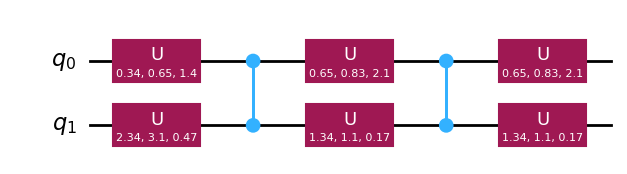

In [42]:
# show intial block
q_1.draw('mpl')

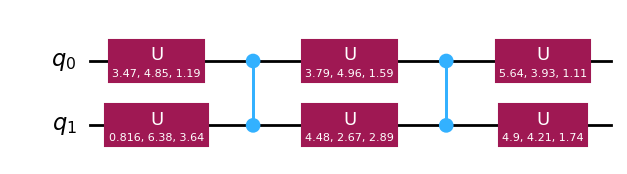

In [43]:
# show found block with similar matrix
q_2.draw('mpl')

### Product of Z and U3. Circuit Z U3(\theta, \phi, \lambda) = U3(\theta, \phi, PI + \lambda).

In [44]:
#Product of Z and U3. Circuit Z U3(\theta, \phi, \lambda) = U3(\theta, \phi, PI + \lambda).
#Do not confuze with product Z*U3, since the operators order in the circuit is opposite
# Z U3 in the circuit assumes applization of U3 * Z to the qubit
q_1 = qiskit.QuantumCircuit(1)
th = 4
ph = 2.7
lam = 2
q_1.z(0)
q_1.u(th, ph, lam, 0)

op = Operator(q_1)
display(array_to_latex(op, precision=2))




q_2 = qiskit.QuantumCircuit(1)
q_2.u(th, ph, lam + PI, 0)

op = Operator(q_2)
display(array_to_latex(op, precision=2))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Product of X and U3. Circuit U3(\theta, \phi, \lambda) X = U3(-\theta + pi, -\phi, \lambda - PI) * exp(1j * \phi).

In [8]:
#Product of X and U3. Circuit U3(\theta, \phi, \lambda) X = U3(-\theta + pi, -\phi, \lambda - PI) * exp(1j * \phi).
#Do not confuze with product X*U3, since the operators order in the circuit is opposite
# X U3 in the circuit assumes applization of U3 * X to the qubit
q_1 = qiskit.QuantumCircuit(1)
th = PI/2
ph = 2
lam = 3

q_1.u(th, ph, lam, 0)
q_1.x(0)

op = Operator(q_1)
display(array_to_latex(op, precision=1))




q_2 = qiskit.QuantumCircuit(1)
q_2.u(-th + PI, -ph, lam - PI, 0)

op = cmath.exp(1j * ph) * Operator(q_2)
display(array_to_latex(op, precision=1))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Commuting X and U3. Circuit X U3(\theta, \phi, \lambda)  = U3(\theta, -\phi + PI, -\lambda + PI)  X * exp(1j * (\phi+\lambda)).

In [29]:
#commuting X and U3. Circuit X U3(\theta, \phi, \lambda)  = U3(\theta, -\phi + PI, -\lambda + PI)  X * exp(1j * (\phi+\lambda)).
q_1 = qiskit.QuantumCircuit(2)
th = PI/3
ph = 2
lam = 3

q_1.x(0)
q_1.u(th, ph, lam, 0)
q_1.u(th, ph, lam, 1)

q_1.cz(0,1)
q_1.u(th, ph*0.45, lam/2, 0)
q_1.u(th, ph, lam, 1)
q_1.cz(0,1)
q_1.u(th, ph+0.3, lam, 0)
q_1.u(th-0.5, ph, lam, 1)

op = Operator(q_1)
display(array_to_latex(op, precision=1))




q_2 = qiskit.QuantumCircuit(2)
q_2.u(th, PI - ph, PI  - lam, 0)
q_2.x(0)
q_2.u(th, ph, lam, 1)

q_2.cz(0,1)
q_2.u(th, ph*0.45, lam/2, 0)
q_2.u(th, ph, lam, 1)
q_2.cz(0,1)
q_2.u(th, ph+0.3, lam, 0)
q_2.u(th-0.5, ph, lam, 1)

op = cmath.exp(1j * (ph + lam)) * Operator(q_2)
display(array_to_latex(op, precision=1))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>